# Instalación de PySpark

In [4]:
# Instalar SDK Java (25 si está disponible, si no 21)
!sudo apt-get update -qq > /dev/null
!sudo apt-get install -y openjdk-25-jdk-headless -qq > /dev/null 2>&1 || \
 sudo apt-get install -y openjdk-21-jdk-headless -qq > /dev/null
!java -version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
[0.048s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.049s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "25.0.4" 2026-07-21
OpenJDK Runtime Environment (build 25.0.4+7-1-22.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 25.0.4+7-1-22.04-Ubuntu, mixed mode, sharing)


In [5]:
# Descargar Spark 4.2.0
!wget -q https://downloads.apache.org/spark/spark-4.2.0/spark-4.2.0-bin-hadoop3.tgz
!ls -lh spark-4.2.0-bin-hadoop3.tgz

-rw-r--r-- 1 root root 530M Jul 11 16:36 spark-4.2.0-bin-hadoop3.tgz


In [6]:
# Descomprimir
!tar xf spark-4.2.0-bin-hadoop3.tgz

In [7]:
# Configurar variables de entorno
import os, glob

java_home = sorted(glob.glob("/usr/lib/jvm/java-*-openjdk-amd64"))[-1]
os.environ["JAVA_HOME"]  = java_home
os.environ["SPARK_HOME"] = "/content/spark-4.2.0-bin-hadoop3"
os.environ["PATH"] = f"{java_home}/bin:" + os.environ["PATH"]

print("JAVA_HOME :", os.environ["JAVA_HOME"])
print("SPARK_HOME:", os.environ["SPARK_HOME"])

JAVA_HOME : /usr/lib/jvm/java-25-openjdk-amd64
SPARK_HOME: /content/spark-4.2.0-bin-hadoop3


In [8]:
# Se desinstala dataproc-spark-connect, que exige pyspark~=4.0.0 y provoca conflicto
!pip uninstall -y -q dataproc-spark-connect

# Instalar findspark
!pip install -q findspark

# Instalar pyspark 4.2.0
!pip install -q pyspark==4.2.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.1/450.1 MB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


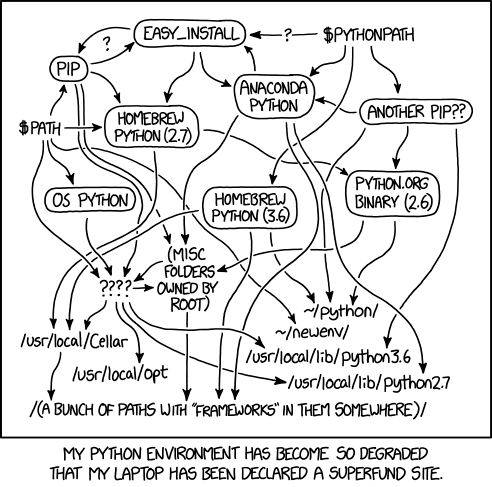

Munroe, R. (2018). Python Environment [Webcómic]. xkcd. https://xkcd.com/1987/

In [9]:
# Se importa la libreria findspark
import findspark

findspark.init()

In [10]:
# Se importa SparkSession de pyspark.sql
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("PruebaSpark420")
         .master("local[*]")
         .getOrCreate())

print("Spark version :", spark.version)
print("Java version  :", spark._jvm.System.getProperty("java.version"))

data = ["hola", "mundo"]
sc = spark.sparkContext
rdd = sc.parallelize(data)

print(rdd.collect())

Spark version : 4.2.0
Java version  : 25.0.4
['hola', 'mundo']


In [11]:
type(rdd)

pyspark.core.rdd.RDD